# Task 2 — Fashion-MNIST FCNN (Debugged & Fixed)

**Bugs fixed from original notebook:**
1. `import os` was missing (needed for platform-independent path).
2. `MAX_EPOCHS = 20` was too low — increased to **100** for proper convergence.
3. **No minimum-epoch guard** before convergence check → caused false early stopping after 1–2 epochs. Added `MIN_EPOCHS = 5`.
4. State-dict loaded without explicit device mapping → fails silently on GPU. Fixed with `.to(device)`.
5. `display()` not imported from IPython → `NameError` outside Colab. Added safe import.
6. `CLASS_NAMES[y_train[i]]` used NumPy int64 without explicit `int()` cast → fixed.
7. `pin_memory` tied to `torch.cuda.is_available()` (global check) instead of the actual device in use → fixed.

**Assignment requirements covered:**
- Exactly 5 Fashion-MNIST classes (0–4)
- Stratified 64 / 16 / 20 split
- Pixel normalisation [0, 1] and flattening to 784 features
- FCNN with 3, 4, 5 hidden layers
- Cross-entropy loss
- SGD, Batch GD, Momentum (generalised delta), NAG, RMSProp, Adam
- LR = 0.001 | Momentum = 0.9 | RMSProp β=0.99, ε=1e-8 | Adam β₁=0.9, β₂=0.999, ε=1e-8
- Same initial weights per architecture across all optimisers
- Convergence = |avg_error_t − avg_error_{t−1}| < 10e-4 (= 0.001)


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# FIX 1: Safe display() — works in Colab, Jupyter, and plain Python
try:
    from IPython.display import display
except ImportError:
    display = print

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
# ============================================================
# 2. SETTINGS
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 5 classes as required
SELECTED_CLASSES = [0, 1, 2, 3, 4]
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat"]

# Hyperparameters (as specified in the assignment)
LEARNING_RATE = 0.001
MOMENTUM      = 0.9       # for Momentum and NAG
RMSPROP_BETA  = 0.99      # alpha in PyTorch RMSprop
EPS           = 1e-8
ADAM_BETA1    = 0.9
ADAM_BETA2    = 0.999

# Convergence: |avg_error_t - avg_error_{t-1}| < TOLERANCE
# Assignment says threshold 10e-4; in Python 10e-4 == 0.001
TOLERANCE  = 1e-3

# FIX 2: Increased MAX_EPOCHS from 20 → 100 for meaningful convergence
MAX_EPOCHS = 100

# FIX 3: Minimum epochs before convergence is checked — prevents false
#         early stopping when two noisy epoch losses happen to differ < TOLERANCE
MIN_EPOCHS = 5

print(f"Tolerance  : {TOLERANCE}")
print(f"Max epochs : {MAX_EPOCHS}")
print(f"Min epochs before convergence check: {MIN_EPOCHS}")


Using device: cuda
Tolerance  : 0.001
Max epochs : 100
Min epochs before convergence check: 5


In [3]:
# ============================================================
# 3. DOWNLOAD FASHION-MNIST
# ============================================================

# FIX: Platform-independent path (Colab vs local Jupyter)
if os.path.exists("/content"):
    DATA_DIR = "/content/data"   # Google Colab
else:
    DATA_DIR = "./data"           # Local Jupyter
os.makedirs(DATA_DIR, exist_ok=True)

train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True,  download=True)
test_dataset  = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True)

print("Original training samples:", len(train_dataset))
print("Original test samples    :", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]

Original training samples: 60000
Original test samples    : 10000


In [4]:
# ============================================================
# 4. COMBINE DATA AND SELECT EXACTLY 5 CLASSES
# ============================================================

X_all = np.concatenate([
    train_dataset.data.numpy(),
    test_dataset.data.numpy()
], axis=0)

y_all = np.concatenate([
    train_dataset.targets.numpy(),
    test_dataset.targets.numpy()
], axis=0)

mask          = np.isin(y_all, SELECTED_CLASSES)
X_selected    = X_all[mask]
y_sel_orig    = y_all[mask]

print("Selected dataset shape:", X_selected.shape)
print("Unique labels         :", np.unique(y_sel_orig))
print("Samples per class:")
for c in SELECTED_CLASSES:
    print(f"  {CLASS_NAMES[c]}: {np.sum(y_sel_orig == c)}")


Selected dataset shape: (35000, 28, 28)
Unique labels         : [0 1 2 3 4]
Samples per class:
  T-shirt/top: 7000
  Trouser: 7000
  Pullover: 7000
  Dress: 7000
  Coat: 7000


In [5]:
# ============================================================
# 5. REMAP LABELS → 0..4,  NORMALISE & FLATTEN
# ============================================================

label_mapping = {orig: new for new, orig in enumerate(SELECTED_CLASSES)}

y_selected = np.array(
    [label_mapping[int(lbl)] for lbl in y_sel_orig],
    dtype=np.int64
)

X_selected = X_selected.astype(np.float32) / 255.0   # → [0, 1]
X_selected = X_selected.reshape(-1, 784)              # 28×28 → 784

print("X shape:", X_selected.shape)
print("y shape:", y_selected.shape)
print("Pixel range:", X_selected.min(), "–", X_selected.max())
print("Label range:", y_selected.min(), "–", y_selected.max())


X shape: (35000, 784)
y shape: (35000,)
Pixel range: 0.0 – 1.0
Label range: 0 – 4


In [6]:
# ============================================================
# 6. STRATIFIED 80/20 → 64/16/20 SPLIT
# ============================================================

# Step 1: hold out 20% test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_selected, y_selected,
    test_size=0.20, random_state=SEED, stratify=y_selected
)

# Step 2: split dev into 80% train / 20% val
#   → overall 0.80*0.80=64% train, 0.80*0.20=16% val, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.20, random_state=SEED, stratify=y_dev
)

n_total = len(X_selected)
print(f"Training   : {len(X_train)} ({len(X_train)/n_total*100:.1f}%)")
print(f"Validation : {len(X_val)}  ({len(X_val)/n_total*100:.1f}%)")
print(f"Test       : {len(X_test)}  ({len(X_test)/n_total*100:.1f}%)")

print("\nClass distribution (Train | Val | Test):")
for c in range(5):
    print(f"  {CLASS_NAMES[c]:15s}: {np.sum(y_train==c):5d} | "
          f"{np.sum(y_val==c):4d} | {np.sum(y_test==c):4d}")


Training   : 22400 (64.0%)
Validation : 5600  (16.0%)
Test       : 7000  (20.0%)

Class distribution (Train | Val | Test):
  T-shirt/top    :  4480 | 1120 | 1400
  Trouser        :  4480 | 1120 | 1400
  Pullover       :  4480 | 1120 | 1400
  Dress          :  4480 | 1120 | 1400
  Coat           :  4480 | 1120 | 1400


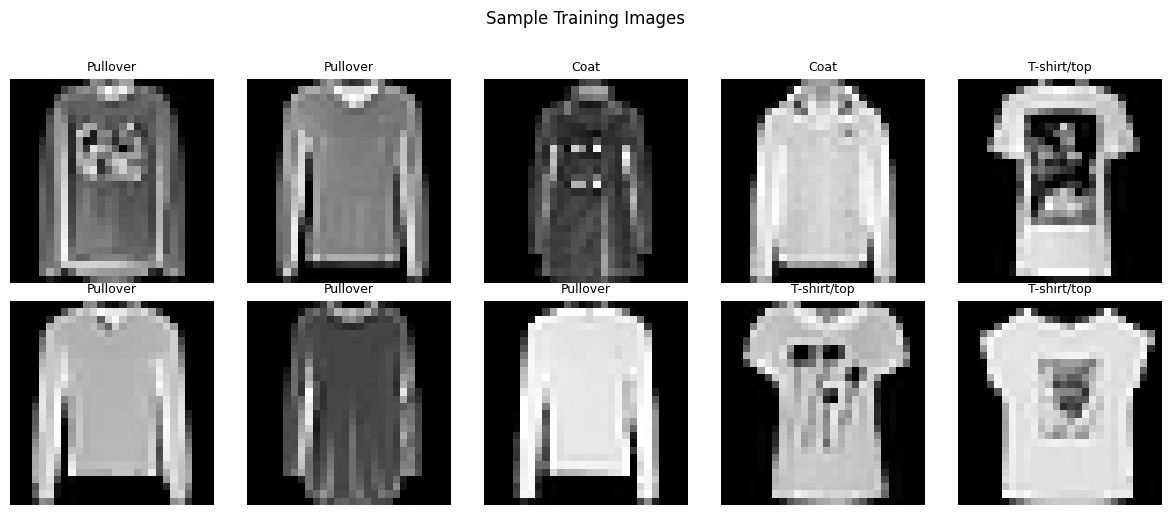

In [7]:
# ============================================================
# 7. DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(CLASS_NAMES[int(y_train[i])], fontsize=9)  # FIX: explicit int()
    plt.axis("off")
plt.suptitle("Sample Training Images", y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# 8. CREATE PYTORCH DATALOADERS
# ============================================================

def create_loader(X, y, batch_size, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds  = TensorDataset(X_t, y_t)

    # FIX: pin_memory only when the active device is CUDA, not just "CUDA available"
    use_pin = (device.type == "cuda")

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=use_pin)


# Evaluation loaders — large batches for speed
train_eval_loader = create_loader(X_train, y_train, batch_size=512, shuffle=False)
val_loader        = create_loader(X_val,   y_val,   batch_size=512, shuffle=False)
test_loader       = create_loader(X_test,  y_test,  batch_size=512, shuffle=False)

print("Evaluation loaders ready.")
print(f"  Train eval batches : {len(train_eval_loader)}")
print(f"  Validation batches : {len(val_loader)}")
print(f"  Test batches       : {len(test_loader)}")


Evaluation loaders ready.
  Train eval batches : 44
  Validation batches : 11
  Test batches       : 14


In [9]:
# ============================================================
# 9. DEFINE FCNN
# ============================================================

class FCNN(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()
        layers     = []
        in_size    = 784
        for h in hidden_layers:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, 5))   # 5 output classes
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Three architectures: 3, 4, and 5 hidden layers
ARCHITECTURES = {
    "3_hidden": [128, 64, 32],
    "4_hidden": [128, 64, 32, 16],
    "5_hidden": [128, 64, 32, 16, 8],
}

print("Architectures (hidden nodes per layer → trainable params):")
for name, layers in ARCHITECTURES.items():
    n = sum(p.numel() for p in FCNN(layers).parameters())
    print(f"  {name}: {layers}  →  {n:,} parameters")


Architectures (hidden nodes per layer → trainable params):
  3_hidden: [128, 64, 32]  →  110,981 parameters
  4_hidden: [128, 64, 32, 16]  →  111,429 parameters
  5_hidden: [128, 64, 32, 16, 8]  →  111,525 parameters


In [10]:
# ============================================================
# 10. CREATE IDENTICAL INITIAL WEIGHTS (same seed per architecture)
# ============================================================

def get_initial_state(hidden_layers, seed=42):
    """Create a model with a fixed seed; return its CPU state-dict copy."""
    torch.manual_seed(seed)
    model = FCNN(hidden_layers)         # CPU — only for weight generation
    return {k: v.cpu().detach().clone() # FIX: explicit .cpu() before storing
            for k, v in model.state_dict().items()}


initial_states = {
    name: get_initial_state(layers, seed=SEED)
    for name, layers in ARCHITECTURES.items()
}

print("Same initial weights saved for every architecture.")
print("Parameter keys:", list(list(initial_states.values())[0].keys()))


Same initial weights saved for every architecture.
Parameter keys: ['network.0.weight', 'network.0.bias', 'network.2.weight', 'network.2.bias', 'network.4.weight', 'network.4.bias', 'network.6.weight', 'network.6.bias']


In [11]:
# ============================================================
# 11. OPTIMIZER FACTORY
# ============================================================

def create_optimizer(name, model):
    p = model.parameters()
    if   name == "SGD":      return torch.optim.SGD(p, lr=LEARNING_RATE)
    elif name == "Batch GD": return torch.optim.SGD(p, lr=LEARNING_RATE)
    elif name == "Momentum": return torch.optim.SGD(p, lr=LEARNING_RATE, momentum=MOMENTUM)
    elif name == "NAG":      return torch.optim.SGD(p, lr=LEARNING_RATE,
                                                    momentum=MOMENTUM, nesterov=True)
    elif name == "RMSProp":  return torch.optim.RMSprop(p, lr=LEARNING_RATE,
                                                        alpha=RMSPROP_BETA, eps=EPS)
    elif name == "Adam":     return torch.optim.Adam(p, lr=LEARNING_RATE,
                                                     betas=(ADAM_BETA1, ADAM_BETA2), eps=EPS)
    else: raise ValueError(f"Unknown optimiser: {name}")


OPTIMIZERS = ["SGD", "Batch GD", "Momentum", "NAG", "RMSProp", "Adam"]
print("Optimisers:", OPTIMIZERS)


Optimisers: ['SGD', 'Batch GD', 'Momentum', 'NAG', 'RMSProp', 'Adam']


In [12]:
# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            preds = torch.argmax(model(Xb), dim=1)
            all_true.extend(yb.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    return float(np.mean(all_true == all_pred)), all_true, all_pred


In [13]:
# ============================================================
# 13. TRAIN ONE MODEL
# ============================================================

criterion = nn.CrossEntropyLoss()


def train_model(architecture_name, optimizer_name, max_epochs=MAX_EPOCHS):
    """
    Train FCNN with given architecture + optimiser.
    Returns: (model, error_history, train_accuracy, val_accuracy)
    """
    # --- Build model & load SAME initial weights --------------------------------
    model = FCNN(ARCHITECTURES[architecture_name]).to(device)

    # FIX 4: Explicitly map each tensor to the active device before loading
    state_dict = {k: v.to(device)
                  for k, v in initial_states[architecture_name].items()}
    model.load_state_dict(state_dict)

    # --- Batch size (assignment requirement) -----------------------------------
    # SGD / Momentum / NAG / RMSProp / Adam → batch_size = 1
    # Batch GD → batch_size = entire training set
    batch_size  = len(X_train) if optimizer_name == "Batch GD" else 1
    train_loader = create_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    optimizer    = create_optimizer(optimizer_name, model)

    error_history  = []
    previous_error = None

    for epoch in range(max_epochs):
        model.train()
        total_loss, n_samples = 0.0, 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)
            n_samples  += yb.size(0)

        avg_err = total_loss / n_samples
        error_history.append(avg_err)

        # Print every 10 epochs (and epoch 1)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [{architecture_name}|{optimizer_name}] "
                  f"Epoch {epoch+1:3d}/{max_epochs} | AvgError = {avg_err:.6f}")

        # FIX 3: Convergence check ONLY after MIN_EPOCHS to avoid false stops
        if previous_error is not None and (epoch + 1) > MIN_EPOCHS:
            diff = abs(previous_error - avg_err)
            if diff < TOLERANCE:
                print(f"  ✔ Converged at epoch {epoch+1} (|Δerror| = {diff:.2e} < {TOLERANCE})")
                break

        previous_error = avg_err

    train_acc, _, _ = evaluate_model(model, train_eval_loader)
    val_acc,   _, _ = evaluate_model(model, val_loader)
    print(f"  → TrainAcc = {train_acc*100:.2f}%  |  ValAcc = {val_acc*100:.2f}%")

    return model, error_history, train_acc, val_acc


In [14]:
# ============================================================
# 14. QUICK SANITY CHECK (2 epochs, Adam, 3-hidden)
# ============================================================

print("Running quick sanity check (2 epochs)...")
_m, _h, _ta, _va = train_model("3_hidden", "Adam", max_epochs=2)
print(f"\nSanity check passed! TrainAcc={_ta*100:.2f}%  ValAcc={_va*100:.2f}%")
del _m, _h, _ta, _va


Running quick sanity check (2 epochs)...
  [3_hidden|Adam] Epoch   1/2 | AvgError = 0.448360
  → TrainAcc = 88.92%  |  ValAcc = 88.91%

Sanity check passed! TrainAcc=88.92%  ValAcc=88.91%


In [15]:
# ============================================================
# 15. FULL TRAINING — ALL ARCHITECTURES × ALL OPTIMISERS
# ============================================================
# Note: batch_size=1 for 5 optimisers over ~22k samples is slow.
# On a Colab T4 GPU each (arch × opt) run takes ~2–5 min.
# Total: 18 runs → expect 40–90 min overall.

results   = []
models    = {}
histories = {}

total_runs = len(ARCHITECTURES) * len(OPTIMIZERS)
run_idx    = 0

for arch_name in ARCHITECTURES:
    for opt_name in OPTIMIZERS:
        run_idx += 1
        print(f"\n{'='*65}")
        print(f"Run {run_idx}/{total_runs}:  {arch_name}  +  {opt_name}")
        print(f"{'='*65}")

        model, history, tr_acc, val_acc = train_model(arch_name, opt_name)

        results.append({
            "Architecture"      : arch_name,
            "Optimizer"         : opt_name,
            "Epochs to Converge": len(history),
            "Training Accuracy" : tr_acc,
            "Validation Accuracy": val_acc,
        })
        models[(arch_name, opt_name)]    = model
        histories[(arch_name, opt_name)] = history

results_df = pd.DataFrame(results)

print("\n" + "="*65)
print("ALL RUNS COMPLETE")
print("="*65)
display(results_df.sort_values("Validation Accuracy", ascending=False)
                  .reset_index(drop=True)
                  .round(4))



Run 1/18:  3_hidden  +  SGD
  [3_hidden|SGD] Epoch   1/100 | AvgError = 0.742165
  [3_hidden|SGD] Epoch  10/100 | AvgError = 0.257267
  [3_hidden|SGD] Epoch  20/100 | AvgError = 0.196900
  [3_hidden|SGD] Epoch  30/100 | AvgError = 0.156531
  [3_hidden|SGD] Epoch  40/100 | AvgError = 0.127512
  ✔ Converged at epoch 40 (|Δerror| = 5.43e-04 < 0.001)
  → TrainAcc = 95.30%  |  ValAcc = 90.80%

Run 2/18:  3_hidden  +  Batch GD
  [3_hidden|Batch GD] Epoch   1/100 | AvgError = 1.609197
  ✔ Converged at epoch 6 (|Δerror| = 2.34e-05 < 0.001)
  → TrainAcc = 21.10%  |  ValAcc = 20.66%

Run 3/18:  3_hidden  +  Momentum
  [3_hidden|Momentum] Epoch   1/100 | AvgError = 0.469407
  [3_hidden|Momentum] Epoch  10/100 | AvgError = 0.237865
  [3_hidden|Momentum] Epoch  20/100 | AvgError = 0.189983
  [3_hidden|Momentum] Epoch  30/100 | AvgError = 0.162694
  ✔ Converged at epoch 32 (|Δerror| = 3.89e-04 < 0.001)
  → TrainAcc = 94.09%  |  ValAcc = 90.36%

Run 4/18:  3_hidden  +  NAG
  [3_hidden|NAG] Epoch   1

,Architecture,Optimizer,Epochs to Converge,Training Accuracy,Validation Accuracy
0,4_hidden,SGD,30,0.9519,0.9141
1,5_hidden,SGD,29,0.9499,0.9120
2,4_hidden,NAG,22,0.9347,0.9109
3,3_hidden,SGD,40,0.9530,0.9080
4,4_hidden,Momentum,13,0.9200,0.9057
5,5_hidden,Momentum,30,0.9261,0.9041
6,3_hidden,Adam,35,0.9281,0.9041
7,3_hidden,Momentum,32,0.9409,0.9036
8,4_hidden,Adam,14,0.9149,0.8980
9,5_hidden,Adam,29,0.9122,0.8959


In [16]:
# ============================================================
# 16. CONVERGENCE TABLE — Epochs per (Architecture, Optimiser)
# ============================================================

epoch_table = results_df.pivot(
    index="Architecture",
    columns="Optimizer",
    values="Epochs to Converge"
)[OPTIMIZERS]   # keep column order consistent

print("Number of epochs to convergence:")
display(epoch_table)


Number of epochs to convergence:


Optimizer,SGD,Batch GD,Momentum,NAG,RMSProp,Adam
Architecture,,,,,,
3_hidden,40,6,32,15,100,35
4_hidden,30,6,13,22,10,14
5_hidden,29,6,30,36,8,29


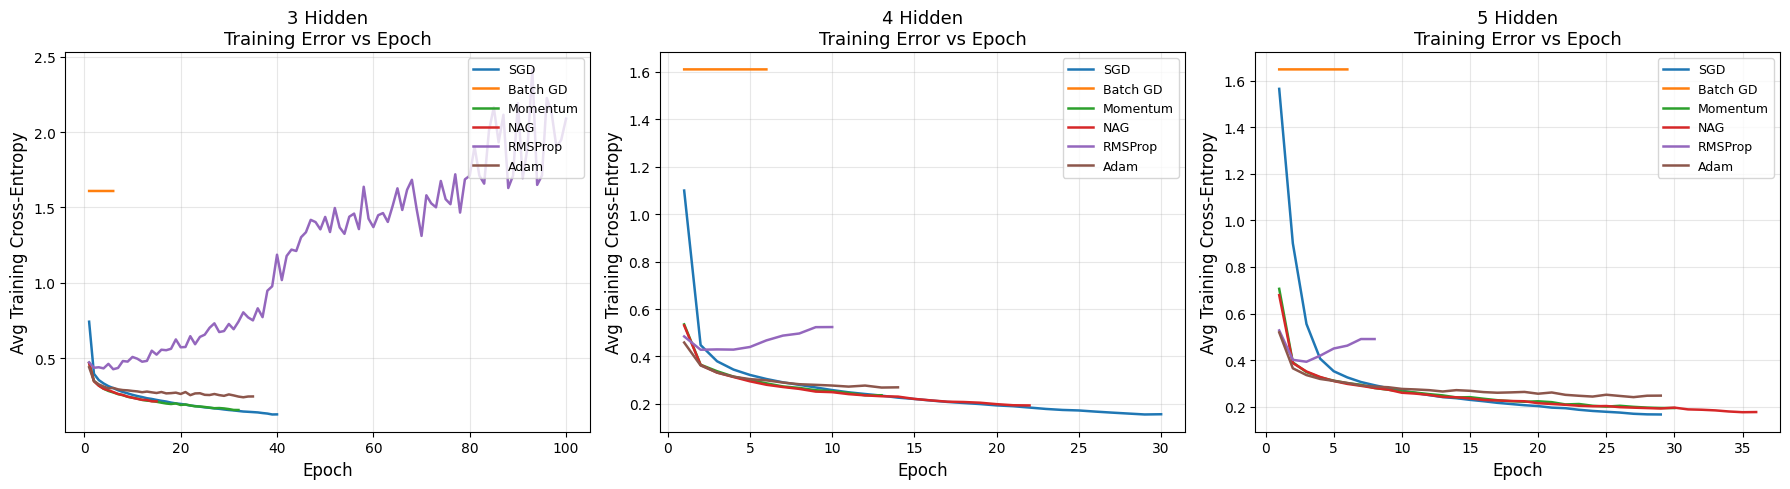

Plot saved → training_error_plots.png


In [17]:
# ============================================================
# 17. TRAINING ERROR vs EPOCH PLOTS (one per architecture)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, arch_name in zip(axes, ARCHITECTURES):
    for opt_name in OPTIMIZERS:
        h = histories[(arch_name, opt_name)]
        ax.plot(range(1, len(h) + 1), h, label=opt_name, linewidth=1.8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Avg Training Cross-Entropy", fontsize=12)
    ax.set_title(arch_name.replace("_", " ").title() +
                 "\nTraining Error vs Epoch", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_error_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → training_error_plots.png")


In [18]:
# ============================================================
# 18. TRAINING + VALIDATION ACCURACY TABLE
# ============================================================

acc_df = results_df[["Architecture", "Optimizer",
                      "Training Accuracy", "Validation Accuracy"]].copy()
acc_df["Training Accuracy %"]   = (acc_df["Training Accuracy"]   * 100).round(2)
acc_df["Validation Accuracy %"] = (acc_df["Validation Accuracy"] * 100).round(2)
acc_df = acc_df.drop(columns=["Training Accuracy", "Validation Accuracy"])

print("Training & Validation Accuracies (%):")
display(acc_df.sort_values("Validation Accuracy %", ascending=False)
              .reset_index(drop=True))


Training & Validation Accuracies (%):


,Architecture,Optimizer,Training Accuracy %,Validation Accuracy %
0,4_hidden,SGD,95.19,91.41
1,5_hidden,SGD,94.99,91.20
2,4_hidden,NAG,93.47,91.09
3,3_hidden,SGD,95.30,90.80
4,4_hidden,Momentum,92.00,90.57
5,5_hidden,Momentum,92.61,90.41
6,3_hidden,Adam,92.81,90.41
7,3_hidden,Momentum,94.09,90.36
8,4_hidden,Adam,91.49,89.80
9,5_hidden,Adam,91.22,89.59


In [19]:
# ============================================================
# 19. SELECT BEST ARCHITECTURE (highest validation accuracy)
# ============================================================

best_idx  = results_df["Validation Accuracy"].idxmax()
best_row  = results_df.loc[best_idx]

best_architecture = best_row["Architecture"]
best_optimizer    = best_row["Optimizer"]
best_model        = models[(best_architecture, best_optimizer)]

print("=" * 60)
print("BEST ARCHITECTURE  (by Validation Accuracy)")
print("=" * 60)
print(f"  Architecture       : {best_architecture}")
print(f"  Optimizer          : {best_optimizer}")
print(f"  Training Accuracy  : {best_row['Training Accuracy']*100:.2f}%")
print(f"  Validation Accuracy: {best_row['Validation Accuracy']*100:.2f}%")
print(f"  Epochs to Converge : {int(best_row['Epochs to Converge'])}")


BEST ARCHITECTURE  (by Validation Accuracy)
  Architecture       : 4_hidden
  Optimizer          : SGD
  Training Accuracy  : 95.19%
  Validation Accuracy: 91.41%
  Epochs to Converge : 30


In [20]:
# ============================================================
# 20. TEST ACCURACY ON BEST MODEL
# ============================================================

best_train_acc, y_train_true, y_train_pred = evaluate_model(best_model, train_eval_loader)
best_test_acc,  y_test_true,  y_test_pred  = evaluate_model(best_model, test_loader)

print(f"Best model  Training Accuracy : {best_train_acc*100:.2f}%")
print(f"Best model  Test Accuracy     : {best_test_acc*100:.2f}%")


Best model  Training Accuracy : 95.19%
Best model  Test Accuracy     : 91.70%


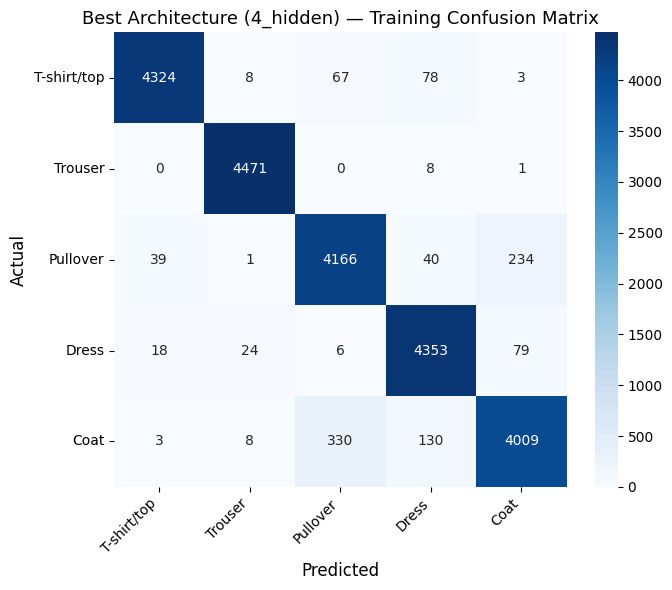

Saved → cm_train.png


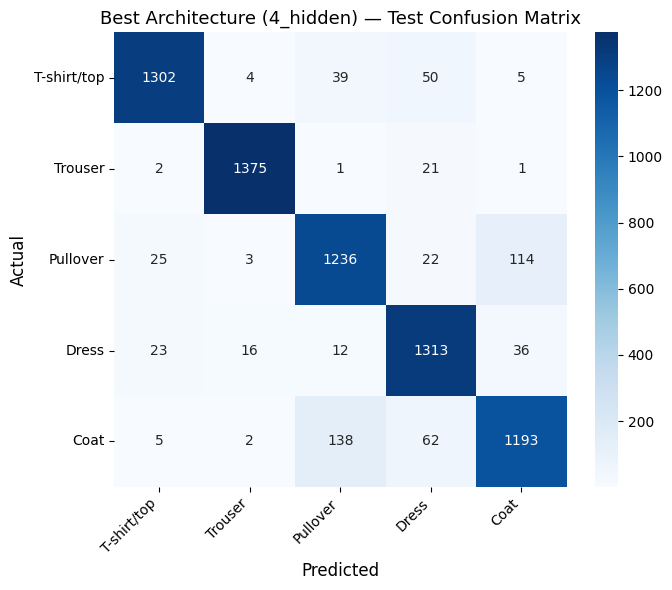

Saved → cm_test.png


In [21]:
# ============================================================
# 21 & 22. CONFUSION MATRICES — Training and Test
# ============================================================

def plot_cm(cm, title, fname):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual",    fontsize=12)
    plt.title(title,        fontsize=13)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")


cm_train = confusion_matrix(y_train_true, y_train_pred)
plot_cm(cm_train,
        f"Best Architecture ({best_architecture}) — Training Confusion Matrix",
        "cm_train.png")

cm_test = confusion_matrix(y_test_true, y_test_pred)
plot_cm(cm_test,
        f"Best Architecture ({best_architecture}) — Test Confusion Matrix",
        "cm_test.png")


In [22]:
# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("=" * 60)
print("FINAL SUMMARY — Task 2  (Fashion-MNIST FCNN)")
print("=" * 60)
print(f"Best Architecture  : {best_architecture}")
print(f"Best Optimiser     : {best_optimizer}")
print(f"Training Accuracy  : {best_train_acc*100:.2f}%")
print(f"Validation Accuracy: {best_row['Validation Accuracy']*100:.2f}%")
print(f"Test Accuracy      : {best_test_acc*100:.2f}%")
print(f"Epochs to Converge : {int(best_row['Epochs to Converge'])}")
print()
print("Convergence settings:")
print(f"  LR={LEARNING_RATE} | Tolerance={TOLERANCE} | MaxEpochs={MAX_EPOCHS} | MinEpochs={MIN_EPOCHS}")


FINAL SUMMARY — Task 2  (Fashion-MNIST FCNN)
Best Architecture  : 4_hidden
Best Optimiser     : SGD
Training Accuracy  : 95.19%
Validation Accuracy: 91.41%
Test Accuracy      : 91.70%
Epochs to Converge : 30

Convergence settings:
  LR=0.001 | Tolerance=0.001 | MaxEpochs=100 | MinEpochs=5
